### Scraping Dashboard API for triggers/s over time

#### This could be pretty easily updated to make work for any info availible at https://habon-ifcb.whoi.edu/api/bin/D20251128T104232_IFCB127?&dataset=mvco

example syntax:
{
  "scale": 0.33,
  "shape": [600, 800],
  "previous_bin_id": "D20251128T102008_IFCB127",
  "next_bin_id": "",
  "lat": 41.325,
  "lng": -70.5667,
  "lat_rounded": "41.325",
  "lng_rounded": "-70.5667",
  "depth": 4,
  "pages": [0, 1],
  "num_pages": 1,
  "tags": [],
  "coordinates": [],
  "has_blobs": false,
  "has_features": false,
  "timestamp_iso": "2025-11-28T10:42:32+00:00",
  "instrument": "IFCB127",
  "num_triggers": 10366,
  "num_images": 8519,
  "trigger_freq": 8.661,
  "ml_analyzed": "1.774 ml",
  "size": 46514213,
  "datasets": [
    "mvco"
  ],
  "primary_dataset": "mvco",
  "comments": [],
  "concentration": 4801.947,
  "skip": false,
  "sample_type": "",
  "cruise": "",
  "cast": "",
  "niskin": null,
  "modified": "2026-07-02T12:25:55.325Z",
  "accessioned": null
}


In [24]:
import json
import time
from pathlib import Path

import pandas as pd
import requests

from concurrent.futures import ThreadPoolExecutor, as_completed

In [46]:
PID_JSON = "/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/PIDLists/MVCO_FPS_2022_2025.json"   # path to your JSON file
OUT_CSV = "/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/misc/FPS/MVCO_FPS_2022_2025.csv"   # path to your output CSV file

BASE_URL = "https://habon-ifcb.whoi.edu/api/bin"
DATASET = "mvco"            # change if needed


In [30]:
def load_pids(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    if isinstance(data, list):
        return [str(x) for x in data]

    if isinstance(data, dict):
        for key in ["PIDS", "pids", "pid_list", "PID_LIST"]:
            if key in data and isinstance(data[key], list):
                return [str(x) for x in data[key]]

    raise ValueError("JSON must be a list of PIDs or a dict containing a PID list.")
    

pids = load_pids(PID_JSON)
len(pids), pids[:5]

(6,
 ['D20251118T000505_IFCB127',
  'D20251118T002728_IFCB127',
  'D20251118T004952_IFCB127',
  'D20251118T011215_IFCB127',
  'D20251118T013438_IFCB127'])

In [31]:
def fetch_pid(pid, session):
    url = f"{BASE_URL}/{pid}"
    r = session.get(url, params={"dataset": DATASET}, timeout=20)
    r.raise_for_status()
    data = r.json()

    return {
        "PID": pid,
        "Datetime": pd.to_datetime(data["timestamp_iso"], utc=True).tz_convert(None),
        "FPS": data["trigger_freq"],
    }

In [32]:
def build_summary_df(pids, max_workers=8):

    rows = []

    with requests.Session() as session:
        with ThreadPoolExecutor(max_workers=max_workers) as executor:

            futures = {
                executor.submit(fetch_pid, pid, session): pid
                for pid in pids
            }

            for future in as_completed(futures):
                try:
                    rows.append(future.result())
                except Exception as e:
                    pid = futures[future]
                    print(f"{pid}: {e}")

    return (
        pd.DataFrame(rows)
        .sort_values("Datetime")
        .reset_index(drop=True)
    )

In [35]:
pids = load_pids(PID_JSON)

summary_df = build_summary_df(pids)

summary_df.head()

,PID,Datetime,FPS
0,D20220124T201049_IFCB127,2022-01-24 20:10:49,11.572
1,D20220125T120108_IFCB127,2022-01-25 12:01:08,11.114
2,D20220127T191940_IFCB127,2022-01-27 19:19:40,8.178
3,D20220128T122257_IFCB127,2022-01-28 12:22:57,9.660
4,D20220129T120003_IFCB127,2022-01-29 12:00:03,8.317


In [47]:
## Optional once you have the summary_df, you can save it to a CSV file for future use
summary_df.to_csv(OUT_CSV, index=False)

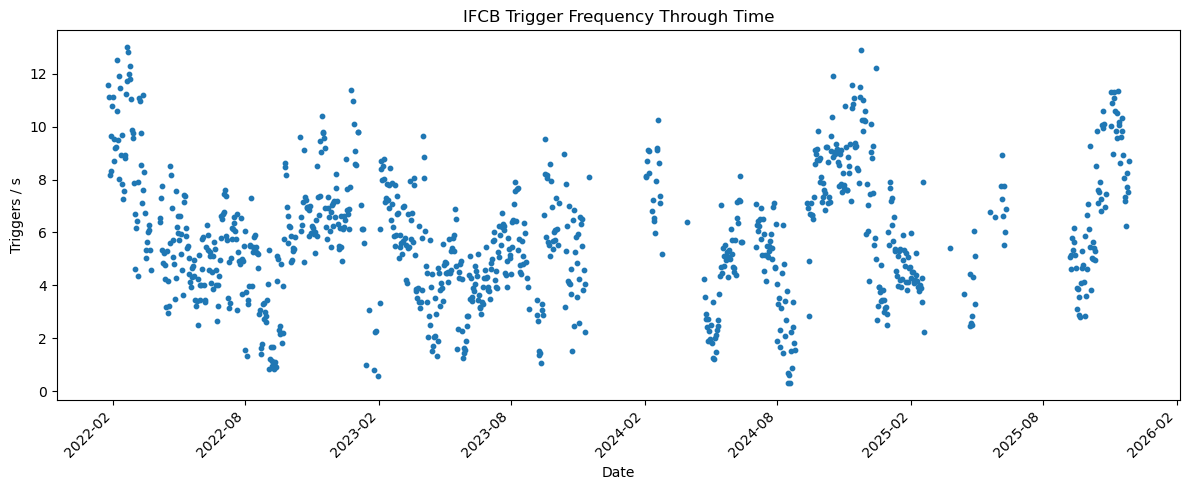

In [38]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Make sure the data are sorted
summary_df = summary_df.sort_values("Datetime")

fig, ax = plt.subplots(figsize=(12, 5))

ax.scatter(
    summary_df["Datetime"],
    summary_df["FPS"],
    s=10,
)

ax.set_xlabel("Date")
ax.set_ylabel("Triggers / s")
ax.set_title("IFCB Trigger Frequency Through Time")

# Put a tick every month
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

# Format as YYYY-MM
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Rotate the labels
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [39]:
def season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

summary_df["Season"] = summary_df["Datetime"].dt.month.apply(season)

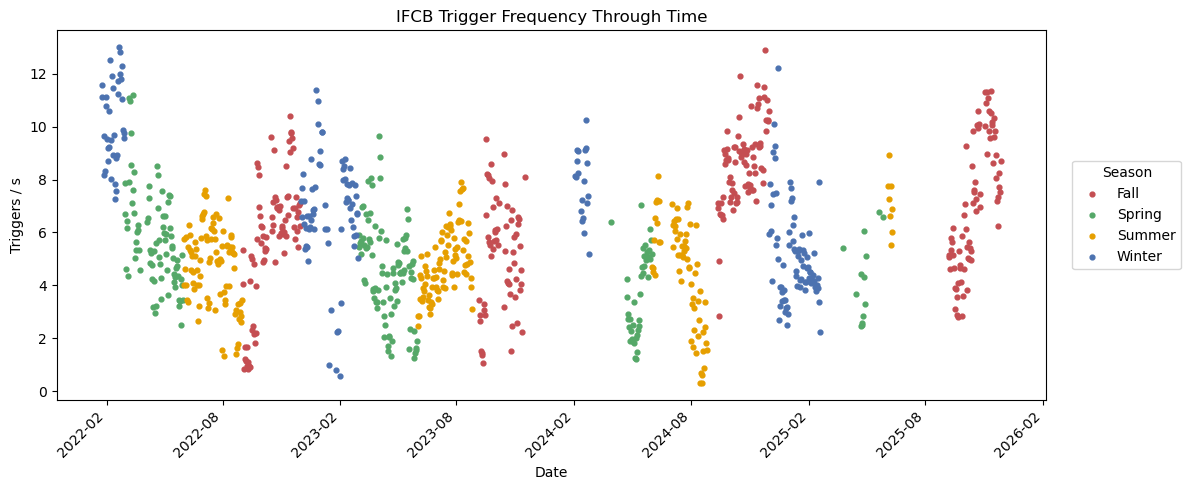

In [45]:
colors = {
    "Winter": "#4C72B0",
    "Spring": "#55A868",
    "Summer": "#E69F00",
    "Fall": "#C44E52",
}

fig, ax = plt.subplots(figsize=(12,5))

for season_name, group in summary_df.groupby("Season"):
    ax.scatter(
        group["Datetime"],
        group["FPS"],
        s=12,
        color=colors[season_name],
        label=season_name,
    )

ax.legend(title="Season",loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

ax.set_xlabel("Date")
ax.set_ylabel("Triggers / s")
ax.set_title("IFCB Trigger Frequency Through Time")

# Put a tick every month
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

# Format as YYYY-MM
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Rotate the labels
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")


ax.set_xlabel("Date")
ax.set_ylabel("Triggers / s")
ax.set_title("IFCB Trigger Frequency Through Time")

plt.tight_layout()
plt.show()


/var/folders/l8/3r0hwyy91wg_66xlwdssv2yr0000gn/T/ipykernel_96250/3842840798.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


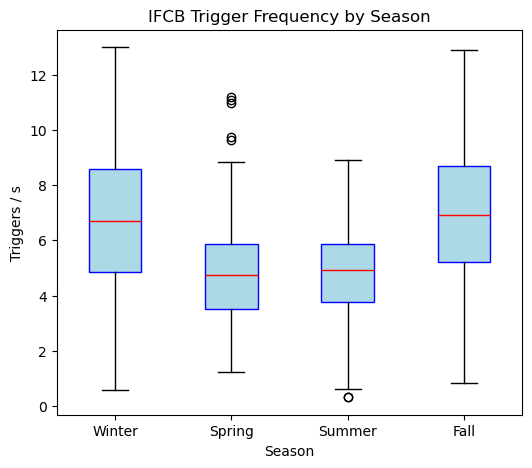

In [52]:
season_order = ["Winter", "Spring", "Summer", "Fall"]

box_data = [
    summary_df.loc[summary_df["Season"] == season, "FPS"].dropna()
    for season in season_order
]

plt.figure(figsize=(6,5))

plt.boxplot(
    box_data,
    labels=season_order,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red"),
)

plt.title("IFCB Trigger Frequency by Season")
plt.xlabel("Season")
plt.ylabel("Triggers / s")

plt.show()

/var/folders/l8/3r0hwyy91wg_66xlwdssv2yr0000gn/T/ipykernel_96250/1747275287.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


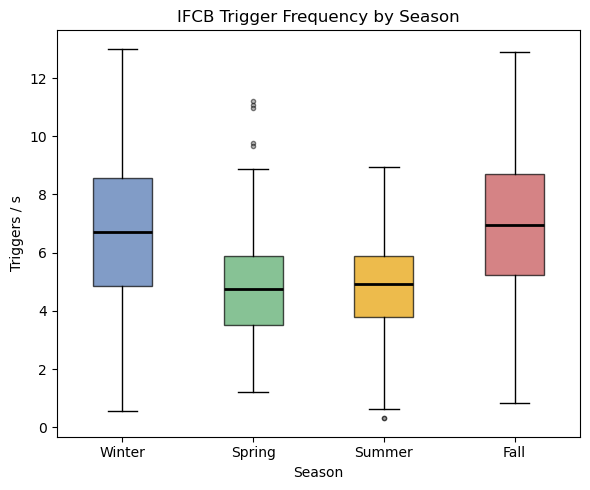

In [57]:
colors = {
    "Winter": "#4C72B0",
    "Spring": "#55A868",
    "Summer": "#E69F00",
    "Fall": "#C44E52",
}

season_order = ["Winter", "Spring", "Summer", "Fall"]

box_data = [
    summary_df.loc[summary_df["Season"] == season, "FPS"].dropna()
    for season in season_order
]

fig, ax = plt.subplots(figsize=(6, 5))

bp = ax.boxplot(
    box_data,
    labels=season_order,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
)

# Color each box
for patch, season in zip(bp["boxes"], season_order):
    patch.set_facecolor(colors[season])
    patch.set_edgecolor("black")
    patch.set_alpha(0.7)

# Optional: color whiskers, caps, and fliers to match
for whisker in bp["whiskers"]:
    whisker.set_color("black")

for cap in bp["caps"]:
    cap.set_color("black")

for flier in bp["fliers"]:
    flier.set(
        marker="o",
        markersize=3,
        markerfacecolor="gray",
        alpha=0.5,
    )

ax.set_title("IFCB Trigger Frequency by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Triggers / s")


plt.tight_layout()
plt.show()